# Demo — end-to-end context inference

One clip, start to finish, through the **GNN–BERT cross-attention fusion** model (Task 3):

`(audio → structure graph)  +  (caption → BERT)  →  cross-attention fusion  →  multi-label tags`

Then two short add-ons: the Task 1 BERT text-only classifier, and Task 4 caption→audio retrieval.

Requires a completed run (checkpoints in `results/checkpoints/`, paired data in
`data/processed/fusion/`). See `README.md` / `RESULTS.md`.

In [1]:
import os, sys, json
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, "src")
get_ipython().run_line_magic("matplotlib", "inline")
import numpy as np, torch
import matplotlib.pyplot as plt
from audio_datasets import load_config
cfg = load_config("config.yaml")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device, "| torch", torch.__version__)

device: cuda | torch 2.11.0+cu128


## 1  Load the fusion model and the paired test set

In [2]:
from analyze_fusion import load_fusion_checkpoint
from data_fusion import FusionDataset, collate_fusion, load_fusion_data
from transformers import AutoTokenizer

ckpt = "results/checkpoints/task3_cross_attention_best.pt"
model, ckpt_cfg, label_vocab, mode = load_fusion_checkpoint(ckpt, device)
cfg["task3"] = ckpt_cfg["task3"]
tok = AutoTokenizer.from_pretrained(cfg["task3"]["model"]["text_model"])

index, graphs, _, _ = load_fusion_data(cfg)
test = index[(index["split"] == "test") & (index["source"] != "deam")].reset_index(drop=True)
ds = FusionDataset(test, graphs, label_vocab, tok, cfg["task3"]["max_length"])
print(f"mode={mode} | {len(ds)} test clips | {len(label_vocab)} tags")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[analysis] loaded results/checkpoints/task3_cross_attention_best.pt (mode=cross_attention, epoch=9)


mode=cross_attention | 4332 test clips | 50 tags


## 2  Pick one clip and show its inputs

In [3]:
# a clip with enough graph structure for the attention to be interesting
i = next(k for k in range(len(ds)) if ds[k]["graph"].num_nodes >= 8)
item = ds[i]
row = test.iloc[i]
g = item["graph"]

print("track_id :", row["track_id"])
print("caption  :", row["text"])
print("graph    :", g.num_nodes, "nodes,", g.edge_index.shape[1], "edges,", g.x.shape[1], "-d node features")
true_tags = [label_vocab[k] for k in np.flatnonzero(item["y_tags"].numpy() > 0)]
print("true tags:", true_tags)

track_id : 2
caption  : Artist: American Bach Soloists. Album: J.S. Bach Solo Cantatas. Title: BWV54 - I Aria.
graph    : 19 nodes, 148 edges, 83 -d node features
true tags: ['classical', 'strings', 'violin', 'opera']


## 3  Forward pass → predicted tags + graph→caption attention

In [4]:
model.eval()
batch = collate_fusion([item])
with torch.no_grad():
    out = model(batch["graph"].to(device),
                batch["input_ids"].to(device),
                batch["attention_mask"].to(device),
                return_attention=True)
probs = torch.sigmoid(out["tag_logits"])[0].float().cpu().numpy()

order = np.argsort(-probs)[:10]
print(f"{'tag':22} prob")
for k in order:
    mark = " <- true" if label_vocab[k] in true_tags else ""
    print(f"{label_vocab[k]:22} {probs[k]:.3f}{mark}")

tag                    prob
classical              0.704 <- true
violin                 0.668 <- true
strings                0.585 <- true
opera                  0.452 <- true
classic                0.127
slow                   0.071
female                 0.057
quiet                  0.052
vocal                  0.042
woman                  0.033


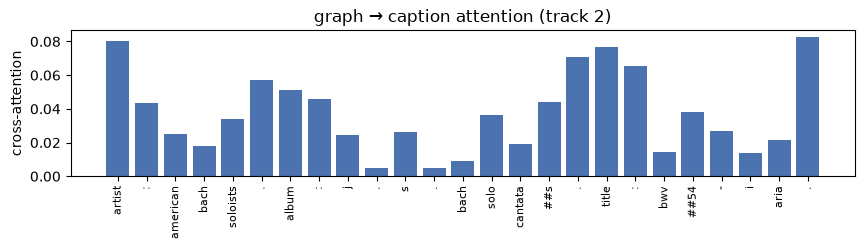

In [5]:
# which caption tokens the graph query attends to
get_ipython().run_line_magic("matplotlib", "inline")  # analyze_fusion import forced Agg
import matplotlib.pyplot as plt
n_real = int(batch["attention_mask"][0].sum())
toks = tok.convert_ids_to_tokens(batch["input_ids"][0][:n_real])
attn = out["attention"][0][:n_real].float().cpu().numpy() if out.get("attention") is not None else np.zeros(n_real)

keep = [j for j, t in enumerate(toks) if t not in ("[CLS]", "[SEP]", "[PAD]")]
plt.figure(figsize=(min(12, 0.35 * len(keep)), 2.6))
plt.bar(range(len(keep)), attn[keep], color="#4c72b0")
plt.xticks(range(len(keep)), [toks[j] for j in keep], rotation=90, fontsize=8)
plt.ylabel("cross-attention"); plt.title(f"graph → caption attention (track {row['track_id']})")
plt.tight_layout(); plt.show()

## 4  Add-on: Task 1 BERT text-only classifier on the same caption

In [6]:
from bert_encoder import BertTagClassifier, build_tokenizer
t1_ckpt = torch.load("results/checkpoints/task1_bert_best.pt", map_location=device, weights_only=False)
t1_vocab = t1_ckpt["label_vocab"]
t1 = BertTagClassifier(t1_ckpt["config"]["model"]["name"], len(t1_vocab),
                       dropout=t1_ckpt["config"]["model"]["dropout"]).to(device)
t1.load_state_dict(t1_ckpt["model_state"]); t1.eval()
t1_tok = build_tokenizer(t1_ckpt["config"]["model"]["name"])
thr = np.load("results/metrics/task1_thresholds.npy")

enc = t1_tok(str(row["text"]), truncation=True, padding="max_length",
             max_length=t1_ckpt["config"]["model"]["max_length"], return_tensors="pt").to(device)
with torch.no_grad():
    p1 = torch.sigmoid(t1(enc["input_ids"], enc["attention_mask"])["logits"])[0].cpu().numpy()
print("Task 1 (text-only) predicted tags:",
      sorted(t1_vocab[k] for k in np.flatnonzero(p1 >= thr)))
print("Note: Task 1 vocab is MusicCaps aspects; this caption is MagnaTagATune metadata, so overlap is limited.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Task 1 (text-only) predicted tags: []
Note: Task 1 vocab is MusicCaps aspects; this caption is MagnaTagATune metadata, so overlap is limited.


## 5  Add-on: Task 4 retrieval — caption query → top-3 audio clips

In [7]:
q = json.load(open("results/retrieval_examples/task4_retrieval_examples.json"))[1]  # a hit@k example
print("query caption:", q["query_caption"])
print("correct clip ranked:", q["rank_of_correct_clip"], "| hit@3:", q["hit_at_k"])
print()
for r in q["retrieved"][:3]:
    print(f"  #{r['rank']}  score {r['score']:.3f}  {'[CORRECT] ' if r['is_correct'] else ''}{r['caption']}")

query caption: 'Atom (medition mix) (Trancevision)' by Magnatune. A music track described as: modern.
correct clip ranked: 1 | hit@3: True

  #1  score 0.821  [CORRECT] 'Atom (medition mix) (Trancevision)' by Magnatune. A music track described as: modern.
  #2  score 0.660  'Linda Morena' by The Headroom Project. A music track described as: foreign, spanish.
  #3  score 0.611  Artist: Memories of Tomorrow. Album: Waiting for Dawn. Title: Waiting for Dawn.


---
### What this shows

- The fusion model takes a real `(graph, caption)` pair and emits calibrated multi-label tag
  probabilities; the attention bar shows which caption tokens the audio structure query weights.
- On MagnaTagATune the caption is only `Artist/Album/Title`, so predictions lean on the graph
  (audio) branch — consistent with the ablation in `RESULTS.md` where `gnn_only` ≈ `concat` > `bert_only`.
- Task 4 retrieval recovers the right artist/album neighbourhood; exact-clip R@1 is low because
  sibling tracks share almost all metadata tokens.